In [2]:
from astropy.io import fits

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.interpolate import RegularGridInterpolator
from scipy.io import readsav
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from tqdm import tqdm

import tools as t

In [3]:
# load files
path_data = '../data/'
data_spectra = fits.getdata(path_data + 'flux_norm_paq12_6173_lionel_tau1_scalingspatial1_sansrotation.fits')
data_rv = readsav(path_data + 'res_rv_bis_6173_lionel_tau1_scaling1_sansrot.sav')
data_rv.keys()

dict_keys(['rv_gauss', 'rv_correl', 'rv_deriv', 'xbiss', 'ybiss', 'l_true', 'lambd', 'flux_moy'])

data_spectra: matrix with 3686 spectra of 122 elements each \
data_rv: dictionary

In [4]:
wl = data_rv['lambd']
rv = data_rv['rv_correl']

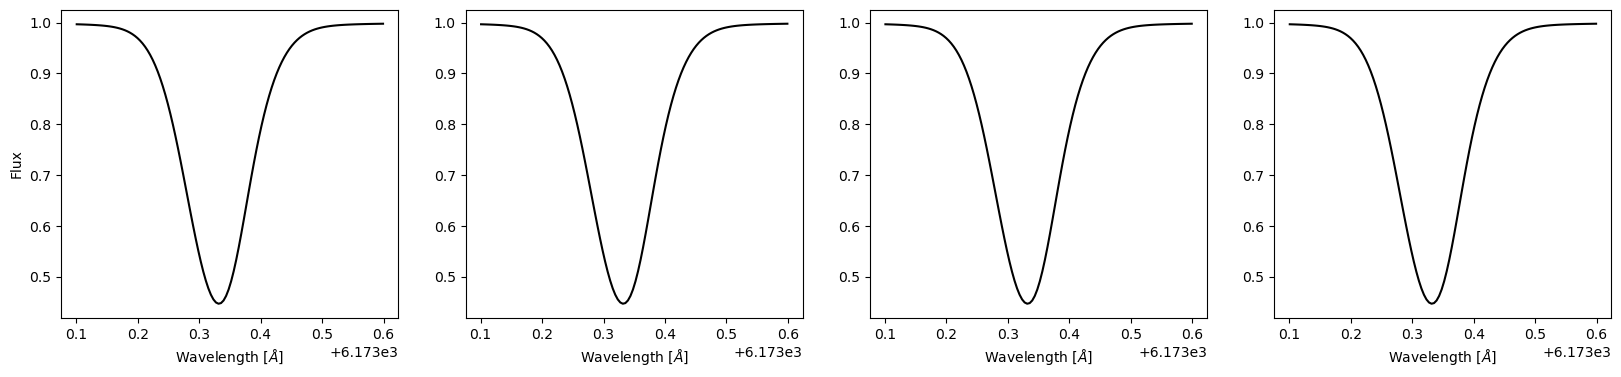

In [5]:
# plot some spectra

n_spectra = 4
fig, axs = plt.subplots(1, n_spectra, figsize=(20, 4))
axs[0].set_ylabel('Flux')
for i in range(n_spectra):
    axs[i].plot(wl, data_spectra[i], color='k')
    axs[i].set_xlabel(r'Wavelength [$\AA$]')
plt.show()


In [6]:
lambda_corr = t.calculate_lambda_corr(wl, rv)